---
title: "Polynomial interpolation"
subtitle: "Lecture 6: Chapter 3: Polynomial interpolation"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

In [1]:
using Plots, LaTeXStrings, Polynomials

function f₁( x )
    return x + rand()
end

function f₂( x )
    return 1/( 1 + exp( x ) );
end

function f₃( x, α = 25 )
    return 1/( 1 + α*x^2 );
end

f₄ = t -> max(0, @. 1-abs(t) );

## Previously.....

* Chapter 1: Floating Point Numbers 
* Chapter 2: Solving Nonlinear Equations in 1d

## Chapter 3: Interpolation

* Before: solution was $\xi \in \mathbb R$, represented numerically as a floating point number
* Now: want to represent a function $f : [a,b] \to \mathbb R$ numerically (*discretisation problem*)

**Interpolation Problem:**

Suppose that $X = \{ x_0 < \cdots < x_n \}$ is a set of distinct *interpolation nodes*, $0 \leq m_0, \dots, m_n \leq m$, and $f$ is an $m$ times differentiable function. 

***Aim***: find $p$ such that 

$$
\begin{align}
    p(x_j) &= f(x_j), \nonumber\\ 
    %
    p'(x_j) &= f'(x_j), \nonumber\\
    %
    &\vdots \nonumber\\
    %
    p^{(m_j)}(x_j) &= f^{(m_j)}(x_j).
\end{align}
$$ {#eq-interpolation}

for all $j = 0, \dots, n$.

::: {#exm-L6-Taylor}
# Taylor polynomial

If $X = \{ x_0 \}$, then we can solve the interpolation problem with a polynomial of degree $m_0$:

\begin{align}
    p(x) &= f(x_0) + f'(x_0)(x-x_0) + \cdots \nonumber\\
    %
    &\qquad+ \frac{f^{(m_0)}(x_0)}{m_0!}(x-x_0)^{m_0}
    %
    \nonumber
\end{align}

:::

::: {#exr-L6-Taylor}

Show that the degree $m_0$ Taylor polynomial of $f$ about $x_0$ solves @eq-interpolation when $X = \{ x_0 \}$.

::: {.exercise-hint style="display:none;"}

Recall that 

\begin{align}
    p(x) = f(x_0) + f'(x_0)(x-x_0) + \cdots + \frac{f^{(m_0)}(x_0)}{m_0!}(x-x_0)^{m_0}
    %
    \nonumber
\end{align}

is the degree $m_0$ Taylor polynomial of $f$ about $x_0$.

:::

:::

::: {#def-Lagrange-interpolant}

If $X = \{ x_0 < \cdots < x_n \}$ and $m_0 = m_1 = \cdots = m_n = 0$, we call @eq-interpolation a *Lagrange interpolation* problem.

:::

::: {#thm-l06-1}
# Lagrange interpolation

For $x_0 < \cdots < x_n$ (*nodes*) and a function $f$ defined on $X = \{x_0,\dots,x_n\}$, there exists a unique polynomial *interpolant* $I_Xf$ of degree at most $n$ such that $I_Xf(x_j) = f(x_j)$ for all $j=0,\dots,n$. 


:::
In the following, we will write $\mathcal P_n := \big\{p(x) = \sum_{j=0}^n a_j x^j \colon a_0, \dots,a_n \in \mathbb R\big\}$ for the set of polynomials of degree at most $n$.

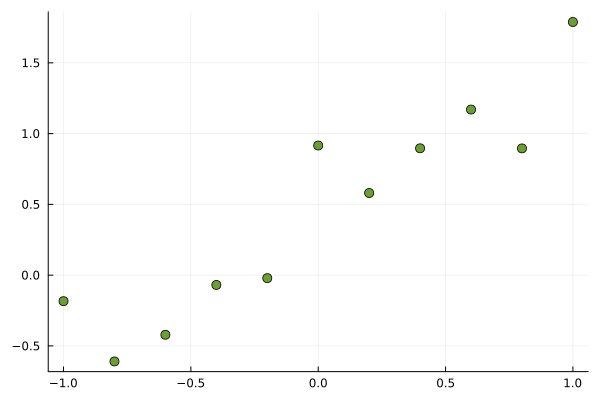

In [2]:
N = 10
X = range( -1, 1, N+1)
Y = f₁.(X)

scatter( X, Y, 
    primary = false, markersize = 5 )

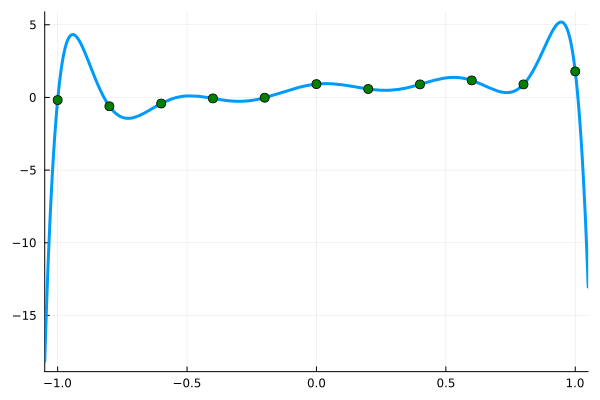

In [3]:
p = fit( X, Y )
plot( p , 
    xlims=(-1.05,1.05), legend = false, lw = 3)
scatter!( X, Y, 
    primary = false, markersize = 5, color="green")

**Proof.** *Existence:* Use the *Lagrange polynomials*:

\begin{align}
    \ell_j(x) = \prod_{k\in\{0,\dots,n\}: \,\, k\not=j} \frac
        {x - x_k}
        {x_j - x_k}
\end{align}

which satsisfy $\ell_j \in \mathcal P_n$ and $\ell_j(x_k) = \delta_{jk}$ for all $j,k=0,\dots,n$.

Notice that 

\begin{align}
    p(x) = \sum_{j=0}^n \ell_j(x) f(x_j)
\end{align}

therefore satisfies $p(x_k) = \sum_{j=0}^n \ell_j(x_k) f(x_j) = \sum_{j=0}^n \delta_{jk} f(x_j) = f(x_k)$ for each $k=0,...,n$. That is $p$ solves the Lagrange interpolation problem. 

*Uniqueness:* suppose that $q \in \mathcal P_n$ interpolates $f$ at $X$. Then, $p - q$ has zeros at each $x_j$, we have that $x - x_j$ divides $p-q$: that is $p(x) - q(x) = \alpha (x - x_0)(x- x_1) \cdots (x - x_n)$. Since $p-q$ only has degree at most $n$, we must have $\alpha=0$ and thus $p = q$. $\square$

Here, we plot the Lagrange polynomials that appear in the above proof:

┌ Info: Saved animation to c:\Users\jack6\Projects\Math5485-Fall-2026\images\Lagrange interpolating polynomials.gif
└ @ Plots C:\Users\jack6\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\jack6\\Projects\\Math5485-Fall-2026\\images\\Lagrange interpolating polynomials.gif")
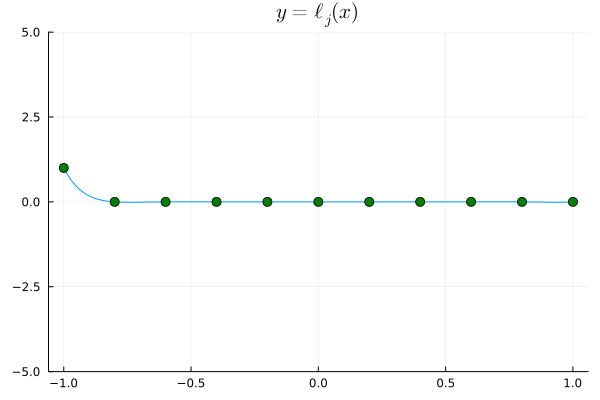

In [4]:
# X = @. cos( π*(0:N)/N )
X = range(-1,1,N+1)

function ℓ( j, x )
    r = 1;
    for n = 0:N
        if (n != j)
            r = r*(x - X[n+1]) / (X[j+1] - X[n+1])
        end
    end
    return r 
end

anim = @animate for j ∈ 0:N
    p = x -> ℓ(j, x)
    plot(p, -1, 1, 
        ylims = (-5, 5), legend = false )
    scatter!( X, p.(X), 
        primary = false, markersize = 5, color="green", title = L"y = \ell_{j}(x)")
end

gif(anim, "../images/Lagrange interpolating polynomials.gif", fps = 1)

::: {#exr-l06-1}

Write down the polynomial of least degree interpolating $f(x) = \sin(x)$ at the points $0, \frac{\pi}{2}, \pi$

:::

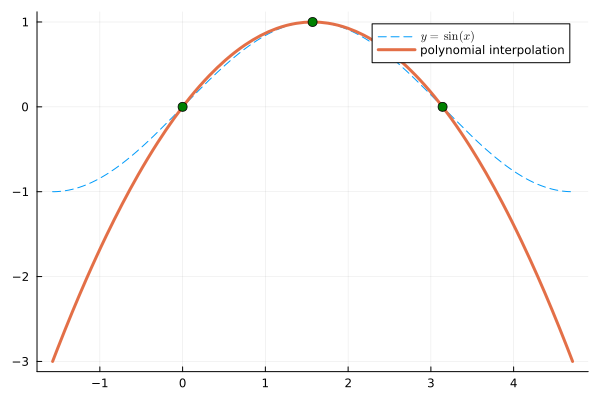

In [5]:
X = 0:(π/2):π
Y = sin.( X )

p = x -> -(4/π^2)*x*(x-π)

plot( x -> sin(x), 
    -π/2, 3π/2, linestyle=:dash, label = L"y = \sin(x)")
plot!( x -> p(x), 
    label = "polynomial interpolation" , lw = 3 )
scatter!( X, Y, 
    primary = false, markersize = 5, color="green")

⬆️ Lecture 6 ⬆️

:::{.callout-tip}
# TO-DO

* Assignment 2: Due on Wednesday!
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

Note: On Wednesday, we will have Problem Class 1.

:::

⬇️ Lecture 7 ⬇️

::: {#thm-Lagrange-interpolation}

Suppose $f:[a,b]\to\mathbb R$ is $n+1$ times continuously differentiable and $X = \{x_0 < \dots < x_n\}$. Then, for all $x \in [a,b]$ there exists $\xi_x \in [\min \{x,x_0\} , \max \{x,x_n\}]$ such that 

\begin{align}
    f(x) - I_Xf(x) = \frac{f^{(n+1)}(\xi_x)}{(n+1)!} (x - x_0)(x-x_1) \cdots (x-x_n)
\end{align}


:::

::: {#rem-Lagrang-interpolation}

Compare with Taylor remainder

:::

**Proof (non-examinable).** For fixed $x \not\in X$, define the function 

\begin{align}
    g(t) = f(t) - I_Xf(t) - \big[ f(x) - I_Xf(x) \big] \prod_{j=0}^n \frac{t - x_j}{x-x_j}.  
\end{align}

Here, $g$ is an $n+1$ times continuously differentiable function with zeros at the $n+2$ distinct points $x, x_0, \dots, x_n$. As a result, by Rolle's theorem (if a differentiable function is zero at its end points, there exists an interior point with zero derivative - the proof follows in the same way as in the proof of the mean value theorem) $g'$ is zero at $n+1$ distinct points, $g''$ is zero at $n$ distinct points, ...., $g^{(n)}$ is zero at $2$ distinct points, and thus there exists $\xi_x \in [\min \{x\} \cup X, \max \{x\}\cup X]$ such that $g^{(n+1)}(\xi_x) = 0$:

\begin{align}
    0 &= g^{(n+1)}(\xi_x) \nonumber\\
      &= f^{(n+1)}(\xi_x) - (I_Xf)^{(n+1)}(\xi_x) - \big[ f(x) - I_Xf(x) \big] \frac{\mathrm{d}^{n+1}}{\mathrm{d}t^{n+1}} \prod_{j=0}^n\frac{t- x_j}{x-x_j}\Bigg|_{t = \xi_x} \nonumber\\
    &= f^{(n+1)}(\xi_x) - \big[ f(x) - I_Xf(x) \big] \frac{(n+1)!}{\prod_{j=0}^n(x-x_j)}, 
\end{align}

as required. $\square$

::: {#exr-Lagrange-int-1}

Write down an error estimate for approximating $f(x) = \sin(x)$ by $I_{\{0, \frac\pi2, \pi\}}f(x) = - \frac4{\pi^2} x (x - \pi)$.


:::


extreme values of q = ±-1.4917901823282596


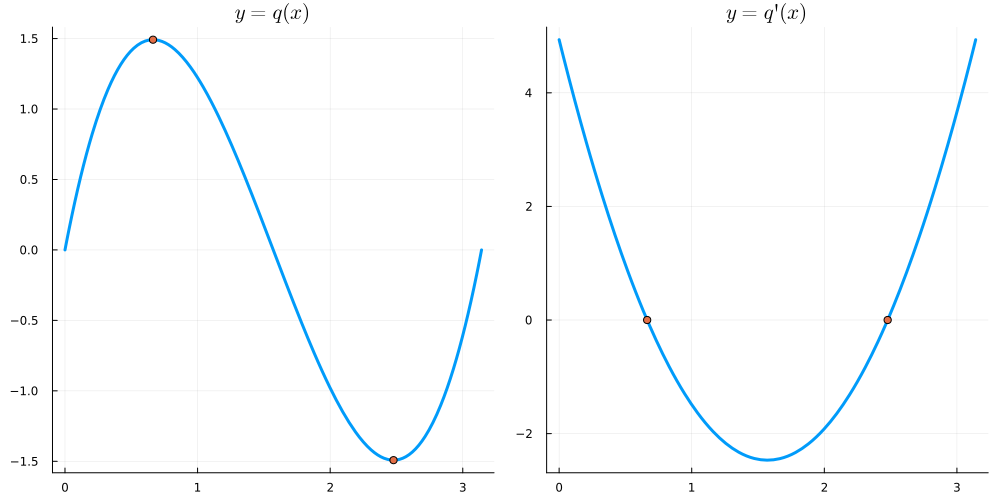

In [6]:
q = x -> x*(x-π/2)*(x-π) 
q′(x) = (x-π/2)*(x-π) + x*(x-π) + x*(x-π/2)

xpm = [ (1/2 + sqrt(3)/6)*π, (1/2 - sqrt(3)/6)*π ]

plt1 = plot( q, 0, π; lw = 3, title=L"y = q(x)", legend=false)
plt2 = plot( q′, 0, π; lw = 3, title=L"y = q'(x)", legend=false)

scatter!( plt1, xpm, q.(xpm) )
scatter!( plt2, xpm, q′.(xpm) )

println("extreme values of q = ±", q(xpm[1])  )
plot( plt1, plt2, size = (1000,500) )

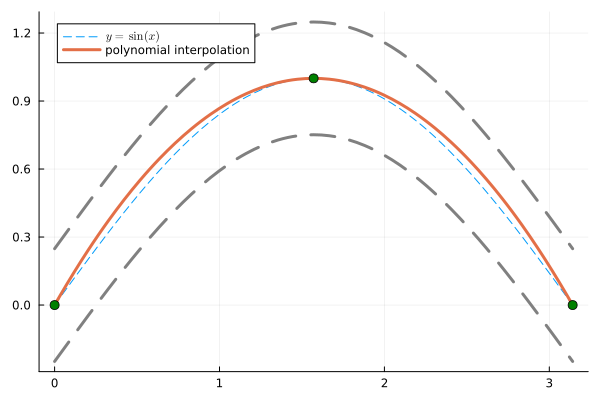

In [7]:
X = 0:(π/2):π
Y = sin.( X )

plot( x -> sin(x) , 0, π, linestyle=:dash, label=L"y = \sin(x)")
plot!( x -> p(x) , label = "polynomial interpolation" , lw = 3 )
scatter!( X, Y, 
    primary = false, markersize = 5, color="green")

err = q( xpm[2] )/6
plot!( x -> sin(x) + err; 
    lw = 3, linestyle=:dash, color="gray", primary = false )    
plot!( x -> sin(x) - err; 
    lw = 3, linestyle=:dash, color="gray", primary = false )    

In general, for $f:[a,b] \to \mathbb R$, $n+1$ times continuously differentiable and $X = \{x_0 < \dots < x_n \}\subset [a,b]$, we have 

\begin{align}
    \left| f(x) - I_Xf(x) \right| \leq \max_{\xi \in [a,b]} |f^{(n+1)}(\xi)| \frac{|\ell_X(x)|}{(n+1)!}  
\end{align}

where $\ell_X(x) := (x-x_0)(x-x_1)\cdots (x-x_n)$ is known as the *node polynomial*.

## Equispaced points

Equispace nodes in $[a,b]$ are given by $X = \{ a + j \frac{b-a}{n} \}_{j=0}^n$. 

::: {#exm-Runge}

Consider $f(x) = \frac{1}{1 + 25 x^2}$.

:::

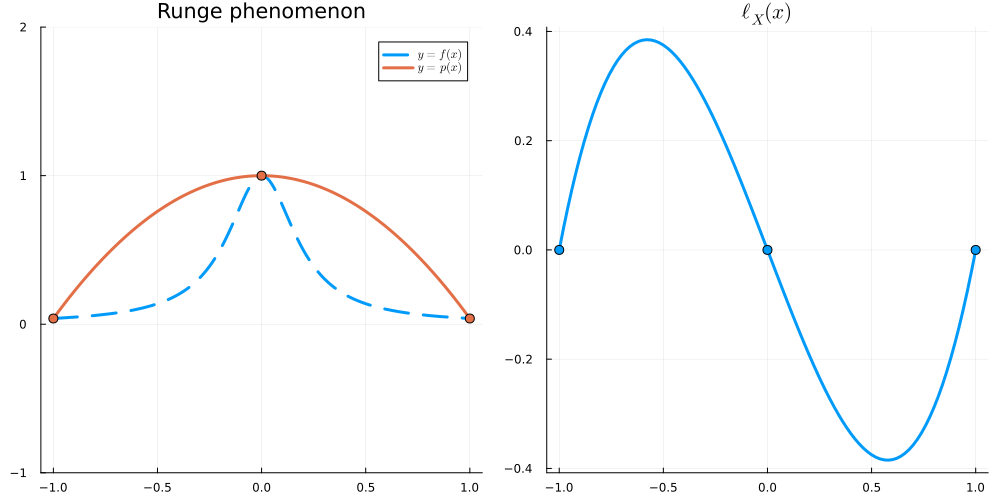

## Chebyshev nodes

Chebyshev nodes (of the second kind) on $[-1,1]$ are given by

$$
\begin{align}
    X = \Big\{ \cos \frac{j\pi}{n} \Big\}_{j=0}^n
\end{align}
$$ {#eq-Chebyshev-nodes}

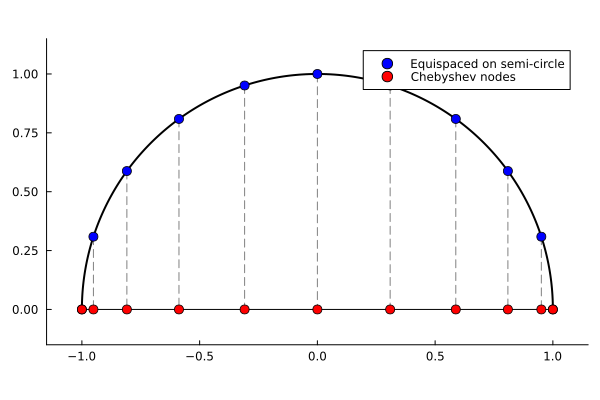

In [8]:
n = 10                                   
θ = range(0, π, length=n+1)          
px, py = cos.(θ), sin.(θ)            

t = range(0, π, length=400)
plt = plot(cos.(t), sin.(t);  lw = 2, color = :black, label = "",
        aspect_ratio = :equal, legend = :topright,
        xlims = (-1.15, 1.15), ylims = (-0.15, 1.15), grid = false)
plot!(plt, [-1, 1], [0, 0], color = :black, lw = 1, label = "")

for j in eachindex(px)
    plot!(plt, [px[j], px[j]], [py[j], 0];
        ls = :dash, color = :gray, label = "")
end

scatter!(plt, px, py; 
    ms = 5, color = :blue, label = "Equispaced on semi-circle")

scatter!(plt, px, zeros(length(px));
    ms = 5, color = :red, label = "Chebyshev nodes")

┌ Info: Saved animation to c:\Users\jack6\Projects\Math5485-Fall-2026\images\Chebyshev.gif
└ @ Plots C:\Users\jack6\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\jack6\\Projects\\Math5485-Fall-2026\\images\\Chebyshev.gif")
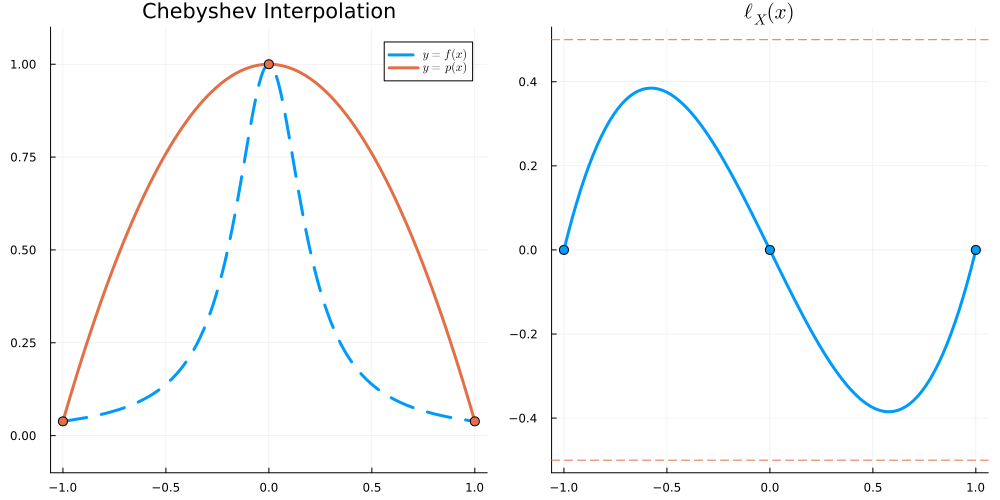

In [9]:
# | include: false

N = 25

err = zeros(N)
egrid = -1:.01:1

anim = @animate for n ∈ 2:N
    x = @. cos( π*(0:n)/n )
    y = @. f₃( x )

    p = fit(ChebyshevT, x, y)

    plt1 = plot(f₃, -1, 1;  
            label=L"y = f(x)", lw = 3, linestyle = :dash, title = "Chebyshev Interpolation")
    plot!(plt1, p, -1, 1;
            label=L"y = p(x)", lw = 3 )
    scatter!(plt1, [x], [y]; 
            primary = false, ylims=(-.1,1.1), markersize = 5)

    ℓ = fromroots( x )
    plt2 = plot(ℓ, -1, 1; 
            title=L"\ell_X(x)", legend = false, lw = 3)
    scatter!(plt2, [x], [zeros(n)];
            primary = false, markersize = 5)

    hline!(plt2, [2.0^(1-n), -2.0^(1-n)]; linestyle=:dash )
    plot( plt1, plt2; size=(1000, 500))
    err[n] = maximum( @. abs( p(egrid) - f₃(egrid) ) )
end

gif(anim, "../images/Chebyshev.gif", fps = 1)

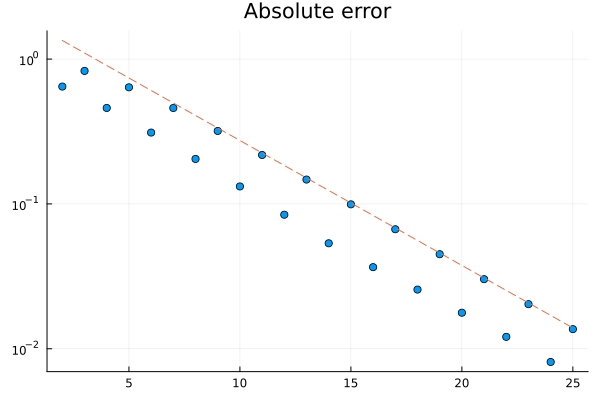

In [10]:
scatter( 2:N, err[2:end] ; 
    yaxis= :log, title="Absolute error", legend=false, lw = 3)
plot!(2:N, @. 2*((1+sqrt(26))/5)^(- (2:N) ); 
    linestyle = :dash )

For $x \in [-1,1]$, we have
 
\begin{align}
    |\ell_X(x)| &\leq \frac{e}{2\sqrt{n}} \left( \frac2e \right)^n
    &\text{for Equispaced nodes }  X = \Big\{ \frac{2j-n}{n} \Big\}_{j=0}^n \nonumber\\
    %
    |\ell_X(x)| &\leq 2^{1-n}
    &\text{for Chebyshev nodes } X = \Big\{ \cos \frac{j\pi}{n} \Big\}_{j=0}^n \nonumber
\end{align}

::: {#exm-pres-1}

Possible presentation topic: Numerical study of the convergence behaviour of Chebyshev interpolation. e.g.:

┌ Info: Saved animation to c:\Users\jack6\Projects\Math5485-Fall-2026\images\Hat.gif
└ @ Plots C:\Users\jack6\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\jack6\\Projects\\Math5485-Fall-2026\\images\\Hat.gif")
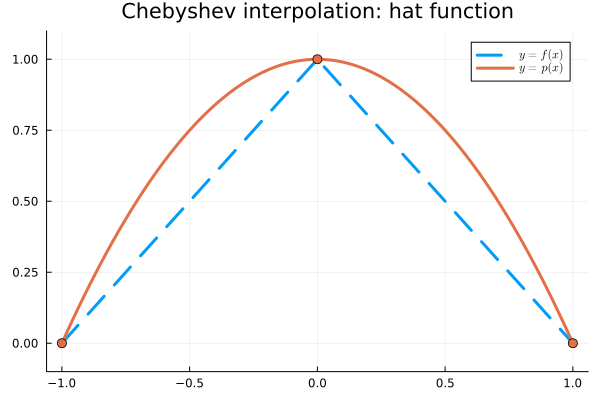

In [11]:
N = 25

err = zeros(N)
egrid = -1:.01:1

anim = @animate for n ∈ 2:N
    x = @. cos( π*(0:n)/n )
    y = @. f₄( x )

    p = fit(ChebyshevT, x, y)

    plt1 = plot(f₄, -1, 1, label=L"y = f(x)", lw = 3, linestyle = :dash, title = "Chebyshev interpolation: hat function")
    plot!(plt1, p, -1, 1, label=L"y = p(x)", lw = 3 )
    scatter!(plt1, [x], [y], primary = false, ylims=(-.1,1.1), markersize = 5)

    err[n] = maximum( @. abs( p(egrid) - f₄(egrid) ) )

end

gif(anim, "../images/Hat.gif", fps = 1)

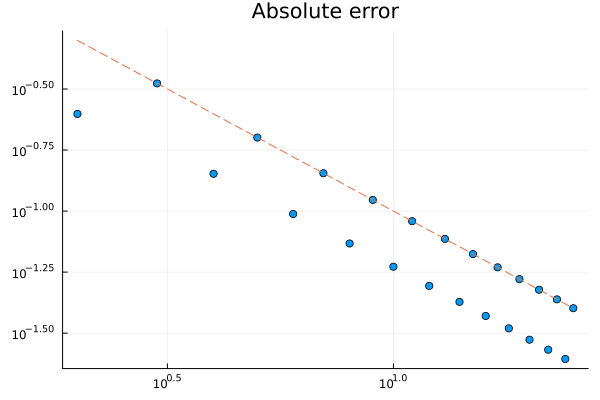

In [12]:
scatter( 2:N, err[2:end]; 
    xaxis= :log, yaxis= :log, title="Absolute error", legend=false, lw = 3)
plot!( 2:N, (2:N).^(-1); 
    linestyle=:dash )

:::

## Extra exercises

::: {#exr-poly-interpolation-2}

Consider $f(x) = e^{-x}$ on $[-1,1]$. 

1. Find a Lagrange interpolating polynomial $p$ of $f$ on $\{ -1, 0 , 1\}$,

2. Write down an error estimate for approximating $f$ with $p$ on $[-1,1]$.

:::

::: {#exr-equispaced-node-poly title="Growth of the equispaced node polynomial"}

**($\star$ more difficult)**

Let $X = \{x_0 < \cdots < x_n\}$ be $n+1$ equispaced nodes on $[-1,1]$, i.e. $x_j = -1 + jh$ with $h = 2/n$, and let $\ell_X(x) = (x-x_0)(x-x_1)\cdots(x-x_n)$ be the node polynomial.

1. Fix $x \in [x_k, x_{k+1}]$ for some $0 \leq k \leq n-1$. By bounding $|x - x_j|$ for $j < k$ and $j > k+1$ and using $|x-x_k|\,|x-x_{k+1}| \leq h^2/4$, show that

   $$
       |\ell_X(x)| \leq \frac{h^{n+1}}{4} (k+1)!\,(n-k)!,
   $$

   and deduce that $\max_{x\in[-1,1]} |\ell_X(x)| \leq \dfrac{n!}{4} h^{n+1}$.

2. Use Stirling's formula, $n! \sim \sqrt{2\pi n}\,(n/e)^n$, to show that there is a constant $C > 0$, independent of $n$, such that

   $$
       \max_{x\in[-1,1]} |\ell_X(x)| \leq C\, \frac{(2/e)^n}{\sqrt n} \qquad \text{for all } n.
   $$

3. By evaluating $\ell_X$ at the point $x^* = x_0 + h/2$, show that there is a constant $c > 0$, independent of $n$, such that

   $$
       \max_{x\in[-1,1]} |\ell_X(x)| \geq c\, \frac{(2/e)^n}{n} \qquad \text{for all } n.
   $$

Note that $2/e \approx 0.736$: parts 2 and 3 together show that $\max\limits_{x\in[-1,1]} |\ell_X(x)|$ decays exponentially, but at a rate no better than $(2/e)^n$.

:::

::: {#exr-Runge-threshold title="A convergence threshold for Runge's example"}

**($\star$ more difficult)**

Fix $\alpha > 0$ and let $f(x) = \dfrac{1}{1+\alpha x^2}$, as in @exm-Runge (with $\alpha=25$).

1. Using the geometric series $f(x) = \sum_{k=0}^\infty (-\alpha)^k x^{2k}$ for $|x| < 1/\sqrt\alpha$, show that

   \begin{align}
       f^{(2k)}(0) &= (2k)!\,(-\alpha)^k, \nonumber\\ 
       f^{(2k+1)}(0) &= 0. \nonumber
   \end{align}

2. Using partial fractions (the poles of $f$ are at $x = \pm i/\sqrt\alpha$), show more generally that

   $$
       \max_{x \in [-1,1]} |f^{(n)}(x)| = n!\, \alpha^{n/2},
   $$

   with the maximum attained at $x=0$.

3. Combine part 2 with @exr-equispaced-node-poly and @thm-Lagrange-interpolation to show that, for $X$ the equispaced nodes on $[-1,1]$,

   $$
       |f(x) - I_Xf(x)| \leq C\sqrt\alpha \, \frac{1}{\sqrt n} \left( \frac{2\sqrt\alpha}{e} \right)^n,
   $$

   and deduce that this bound converges to $0$ whenever $\alpha < \frac{e^2}{4} \approx 1.847$. 

It turns out that we have convergence for all $\alpha < \alpha_{\rm c} \approx 3.621$ @Trefethen, @Epperson.

Next week, we will see that for Chebyshev nodes, the node polynomial instead satisfies $|\ell_X(x)| \leq 2^{1-n}$ and so

$$
    |f(x) - I_Xf(x)| \leq 2\sqrt\alpha \left( \frac{\sqrt\alpha}{2} \right)^n,
$$

which converges to $0$ whenever $\alpha < 4$. (A sharper argument, using that $f$ is analytic throughout a neighbourhood of $[-1,1]$ in $\mathbb C$ rather than just bounding derivatives along the real axis shows that Chebyshev interpolation converges for *all* $\alpha > 0$.)

:::